In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model


In [9]:
base_dir = "data/mushroom_or_not"

classes = ["mushroom", "not_mushroom"]

for cls in classes:
    os.makedirs(os.path.join(base_dir, cls), exist_ok=True)

print("Folders created successfully")


Folders created successfully


In [10]:
import os

mushroom_path = "data/mushroom_or_not/mushroom"
not_mushroom_path = "data/mushroom_or_not/not_mushroom"

print("Mushroom images:", len(os.listdir(mushroom_path)))
print("Not Mushroom images:", len(os.listdir(not_mushroom_path)))

Mushroom images: 74
Not Mushroom images: 72


In [11]:
train_data = datagen.flow_from_directory(
    "data/mushroom_or_not",
    target_size=(224,224),
    batch_size=16,
    class_mode="binary",
    subset="training"
)

val_data = datagen.flow_from_directory(
    "data/mushroom_or_not",
    target_size=(224,224),
    batch_size=16,
    class_mode="binary",
    subset="validation"
)

NameError: name 'datagen' is not defined

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [13]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [14]:
train_data = datagen.flow_from_directory(
    "data/mushroom_or_not",
    target_size=(224,224),
    batch_size=16,
    class_mode="binary",
    subset="training"
)

val_data = datagen.flow_from_directory(
    "data/mushroom_or_not",
    target_size=(224,224),
    batch_size=16,
    class_mode="binary",
    subset="validation"
)

Found 118 images belonging to 2 classes.
Found 28 images belonging to 2 classes.


In [15]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
print("woking")

woking


In [17]:
import os

print("Mushroom:", len(os.listdir("data/mushroom_or_not/mushroom")))
print("Not Mushroom:", len(os.listdir("data/mushroom_or_not/not_mushroom")))

Mushroom: 74
Not Mushroom: 72


In [18]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=12
)

C:\Users\karth\anaconda3\envs\mushroom_ai\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/12
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 817ms/step - accuracy: 0.8000 - loss: 0.4701

C:\Users\karth\anaconda3\envs\mushroom_ai\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


8/8 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.8091 - loss: 0.4525 - val_accuracy: 0.9643 - val_loss: 0.1343
Epoch 2/12
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 903ms/step - accuracy: 0.9615 - loss: 0.1278 - val_accuracy: 0.9643 - val_loss: 0.1782
Epoch 3/12
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 899ms/step - accuracy: 0.9865 - loss: 0.0519 - val_accuracy: 0.9286 - val_loss: 0.3549
Epoch 4/12
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 915ms/step - accuracy: 0.9862 - loss: 0.0279 - val_accuracy: 0.9643 - val_loss: 0.1751
Epoch 5/12
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 932ms/step - accuracy: 1.0000 - loss: 0.0103 - val_accuracy: 0.9286 - val_loss: 0.1257
Epoch 6/12
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 1.0000 - loss: 0.0041 - val_accuracy: 1.0000 - val_loss: 0.0209
Epoch 7/12
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 0.9643 - val_loss: 0.0377
Epoch 8/12
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 914ms/step - accuracy: 1.0000 - loss: 0.0042 - val_accuracy: 0.9643 - val_loss: 0.0675
Epoch 9/1

In [21]:
print("work")

work


In [22]:
model.save("mushroom_or_not_model.h5")
print("Model saved successfully")

Model saved successfully


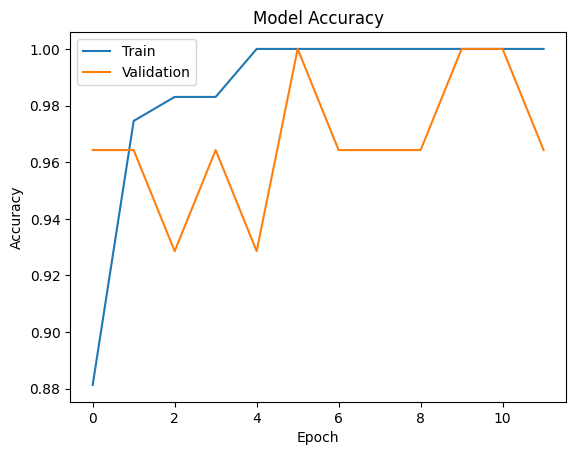

In [23]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [1]:
import tensorflow as tf

model1 = tf.keras.models.load_model("mushroom_or_not_model.h5")
converter1 = tf.lite.TFLiteConverter.from_keras_model(model1)
tflite_model1 = converter1.convert()

with open("mushroom_or_not_model.tflite", "wb") as f:
    f.write(tflite_model1)

print("Stage 1 TFLite saved")

INFO:tensorflow:Assets written to: C:\Users\karth\AppData\Local\Temp\tmpnyx7p6q6\assets


INFO:tensorflow:Assets written to: C:\Users\karth\AppData\Local\Temp\tmpnyx7p6q6\assets


Saved artifact at 'C:\Users\karth\AppData\Local\Temp\tmpnyx7p6q6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2941697158656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2941699862768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2941699863824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2941697279776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2941699862592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2941699866112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2941699879856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2941699880736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2941699879328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2941699879504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  294169